In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


df = pd.read_csv('bike_sharing.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.70,50,26.00,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.43,57,15.00,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.91,61,15.00,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.43,61,6.00,12,117,129


In [13]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.dtypes

,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [14]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.39,81,0.00,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.63,80,0.00,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.63,80,0.00,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.39,75,0.00,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.39,75,0.00,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.70,50,26.00,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.43,57,15.00,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.91,61,15.00,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.43,61,6.00,12,117,129


In [15]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [16]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [17]:

numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered',	'count']
categorical_cols = ['season', 'holiday', 'workingday', 'weather', ]

print("Numeric summary")
display(df[numeric_cols].describe().T)

print("\nSkewness")
display(df[numeric_cols].skew().sort_values(ascending=False).to_frame("skewness"))

print("\nCategorical distributions")
for col in categorical_cols:
    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: (x["count"] / len(df) * 100).round(2))
    )

Numeric summary


,count,mean,std,min,25%,50%,75%,max
temp,"10,886.00",20.23,7.79,0.82,13.94,20.50,26.24,41.00
atemp,"10,886.00",23.66,8.47,0.76,16.66,24.24,31.06,45.45
humidity,"10,886.00",61.89,19.25,0.00,47.00,62.00,77.00,100.00
windspeed,"10,886.00",12.80,8.16,0.00,7.00,13.00,17.00,57.00
casual,"10,886.00",36.02,49.96,0.00,4.00,17.00,49.00,367.00
registered,"10,886.00",155.55,151.04,0.00,36.00,118.00,222.00,886.00
count,"10,886.00",191.57,181.14,1.00,42.00,145.00,284.00,977.00



Skewness


,skewness
casual,2.50
registered,1.52
count,1.24
windspeed,0.59
temp,0.00
humidity,-0.09
atemp,-0.10



Categorical distributions


,count,percent
season,,
4,2734,25.11
2,2733,25.11
3,2733,25.11
1,2686,24.67


,count,percent
holiday,,
0,10575,97.14
1,311,2.86


,count,percent
workingday,,
1,7412,68.09
0,3474,31.91


,count,percent
weather,,
1,7192,66.07
2,2834,26.03
3,859,7.89
4,1,0.01


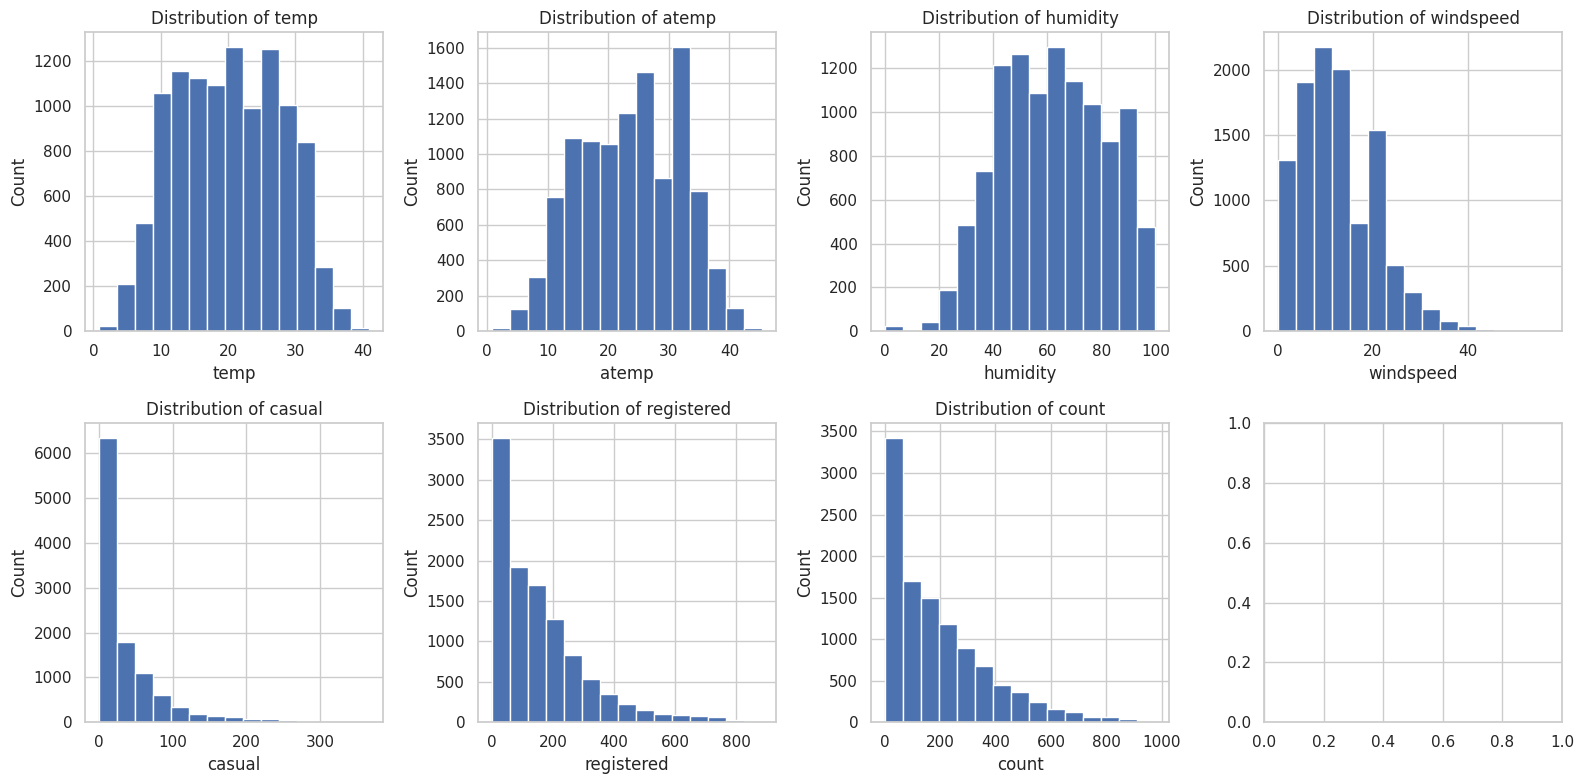

In [18]:
# Univariate distributions for numerical variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=15)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

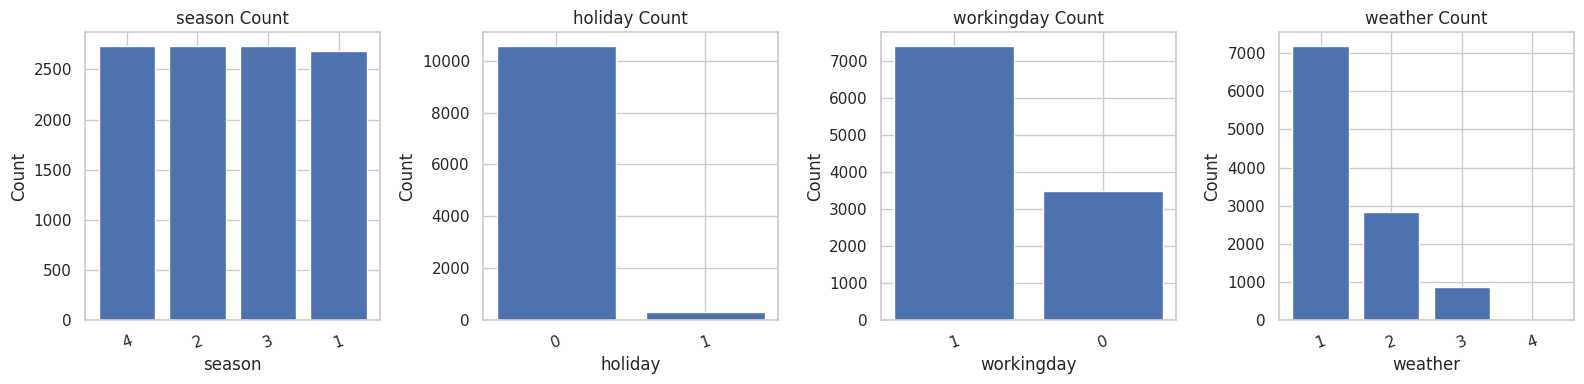

In [19]:

# Product and customer-category counts
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{col} Count")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [10]:

# casual vs categorical
plot_features = categorical_cols
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    plot_table = pd.crosstab(df[feature], df["casual"]) ## do same for registered, count
    plot_table.plot(kind="bar", ax=ax)
    ax.set_title(f"casual by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="casual")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

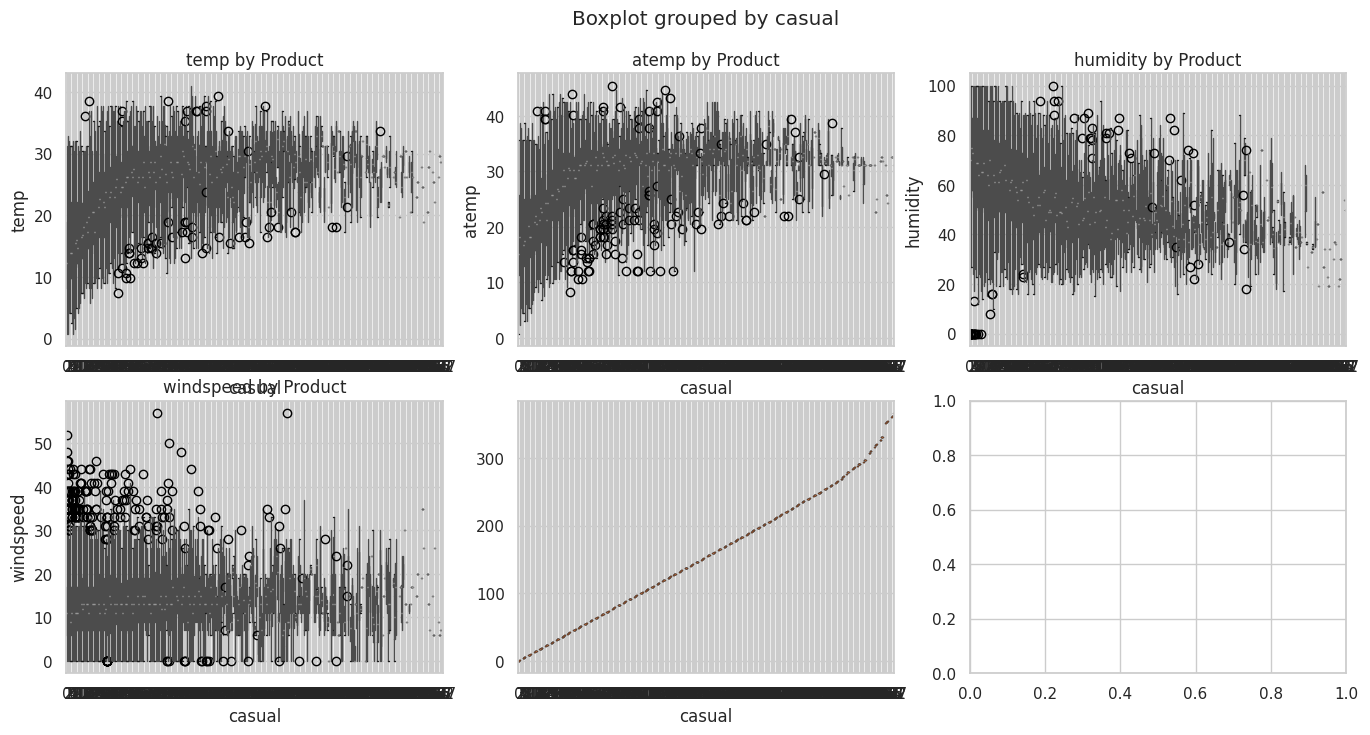

In [11]:
# Product vs numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by="casual", ax=ax)  ## do same for registered, count
    ax.set_title(f"{col} by Product")
    ax.set_xlabel("casual")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.00,0.98,-0.07,-0.02,0.47,0.32,0.39
atemp,0.98,1.00,-0.04,-0.06,0.46,0.32,0.39
humidity,-0.07,-0.04,1.00,-0.32,-0.35,-0.27,-0.32
windspeed,-0.02,-0.06,-0.32,1.00,0.09,0.09,0.10
casual,0.47,0.46,-0.35,0.09,1.00,0.50,0.69
registered,0.32,0.32,-0.27,0.09,0.50,1.00,0.97
count,0.39,0.39,-0.32,0.10,0.69,0.97,1.00


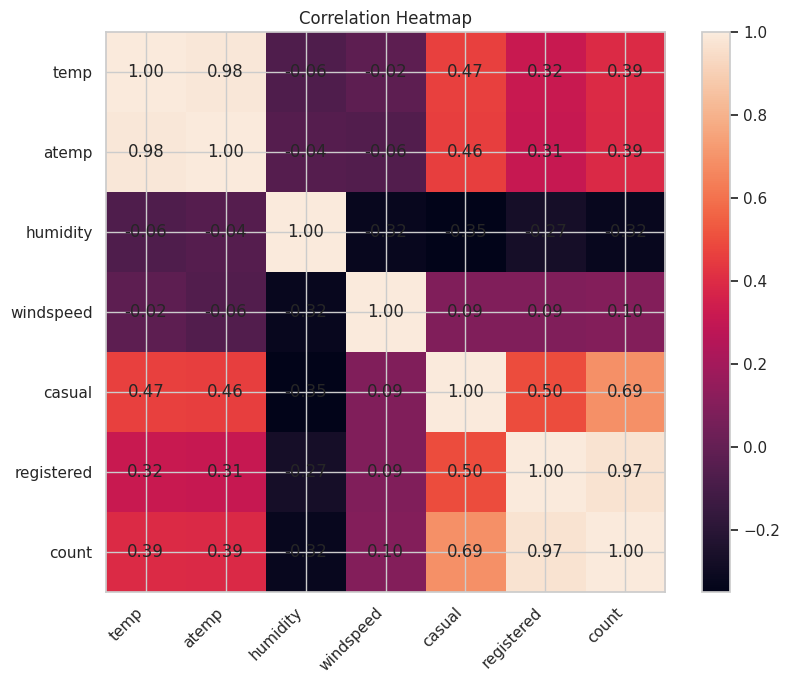

In [20]:
corr = df[numeric_cols].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:

# Optional but useful multivariate view for a small dataset.
RUN_PAIRPLOT = False

if RUN_PAIRPLOT:
    sns.pairplot(df, vars=numeric_cols, hue="casual", diag_kind="hist") ## do same for registered, count
    plt.show()

In [23]:
def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    """Return lower and upper IQR outlier bounds."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


outlier_summary_rows = []
outlier_flag_df = df.copy()

for col in numeric_cols:
    lower, upper = iqr_bounds(outlier_flag_df[col])
    flag_col = f"{col}_Outlier"
    outlier_flag_df[flag_col] = (outlier_flag_df[col] < lower) | (outlier_flag_df[col] > upper)
    outlier_summary_rows.append({
        "Feature": col,
        "Lower_Bound": round(lower, 2),
        "Upper_Bound": round(upper, 2),
        "Outlier_Count": int(outlier_flag_df[flag_col].sum()),
        "Outlier_%": round(outlier_flag_df[flag_col].mean() * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)
display(outlier_summary)

outlier_cols = [f"{col}_Outlier" for col in numeric_cols]
outliers_by_product = (
    outlier_flag_df
    .groupby("casual", observed=True)[outlier_cols]   ## do same for registered, count
    .mean()
    .mul(100)
    .round(2)
)

display(outliers_by_product)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,temp,-4.51,44.69,0,0.00
1,atemp,-4.93,52.65,0,0.00
2,humidity,2.00,122.00,22,0.20
3,windspeed,-7.99,31.99,227,2.09
4,casual,-63.50,116.50,749,6.88
5,registered,-243.00,501.00,423,3.89
6,count,-321.00,647.00,300,2.76


,temp_Outlier,atemp_Outlier,humidity_Outlier,windspeed_Outlier,casual_Outlier,registered_Outlier,count_Outlier
casual,,,,,,,
0,0.00,0.00,0.51,2.03,0.00,0.00,0.00
1,0.00,0.00,1.20,2.10,0.00,0.00,0.00
2,0.00,0.00,0.41,2.05,0.00,0.00,0.00
3,0.00,0.00,0.46,0.68,0.00,0.23,0.00
4,0.00,0.00,0.56,2.54,0.00,0.28,0.00
...,...,...,...,...,...,...,...
356,0.00,0.00,0.00,0.00,100.00,0.00,100.00
357,0.00,0.00,0.00,0.00,100.00,0.00,100.00
361,0.00,0.00,0.00,0.00,100.00,0.00,100.00
